# Bank Marketing Campaign Analysis: Python Modeling After SQL Preparation

This notebook continues the project after the SQL workflow has prepared the analysis-ready data.

SQL Server was used to import the raw CSV, validate data quality, create business-friendly fields, and generate KPI and segment summary views.

Python is used for deeper analysis, visualization, predictive modeling, campaign targeting evaluation, and model interpretation.

This notebook does not repeat the full raw-data cleaning process already completed in SQL.

## 1. Python Setup and SQL Handoff

The notebook connects to the SQL Server views created in the SQL part of the project.

Main SQL view used:

- `vw_bank_marketing_analysis_ready`

Additional SQL summary views used for validation and business review:

- `vw_campaign_kpi`
- `vw_segment_conversion_summary`

If the SQL view contains optional engineered fields, Python can use them for review. If some optional fields are missing, the notebook will continue as long as the required target fields are available.

### 1.1 Import Libraries

In [33]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Statistical association
from scipy.stats import chi2_contingency

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

### 1.2 Load Analysis-Ready Data from SQL Server

Update the `server` value if your SQL Server instance name is different.

This notebook uses Windows Authentication through `Trusted_Connection=yes`.

In [34]:
# SQL Server connection settings
# Check your server name in SSMS Object Explorer if this does not connect.
server = r'localhost\SQLEXPRESS03'
database = 'bank_marketing_project'

try:
    import pyodbc

    # Choose an available SQL Server ODBC driver
    available_drivers = [driver for driver in pyodbc.drivers() if 'SQL Server' in driver]

    if not available_drivers:
        raise RuntimeError(
            "No SQL Server ODBC driver found. Install ODBC Driver 17 or 18 for SQL Server."
        )

    preferred_drivers = [
        'ODBC Driver 18 for SQL Server',
        'ODBC Driver 17 for SQL Server',
        'SQL Server'
    ]

    driver = next(
        (d for d in preferred_drivers if d in available_drivers),
        available_drivers[-1]
    )

    connection_string = (
        f"DRIVER={{{driver}}};"
        f"SERVER={server};"
        f"DATABASE={database};"
        "Trusted_Connection=yes;"
        "TrustServerCertificate=yes;"
    )

    conn = pyodbc.connect(connection_string)

    # Main analysis-ready dataset
    df = pd.read_sql(
        "SELECT * FROM dbo.vw_bank_marketing_analysis_ready;",
        conn
    )

    # SQL summary views for validation/reference
    sql_kpi = pd.read_sql(
        "SELECT * FROM dbo.vw_campaign_kpi;",
        conn
    )

    sql_segments = pd.read_sql(
        "SELECT * FROM dbo.vw_segment_conversion_summary;",
        conn
    )

    conn.close()

    print("SQL connection successful.")
    print(f"Driver used: {driver}")
    print(f"Rows loaded: {df.shape[0]:,}")
    print(f"Columns loaded: {df.shape[1]:,}")

except Exception as e:
    print("SQL connection failed.")
    print("Check your server name, database name, ODBC driver, and whether SQL Server is running.")
    raise e

C:\Users\phanh\AppData\Local\Temp\ipykernel_13604\3139978863.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


SQL connection successful.
Driver used: ODBC Driver 18 for SQL Server
Rows loaded: 45,211
Columns loaded: 24


C:\Users\phanh\AppData\Local\Temp\ipykernel_13604\3139978863.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_kpi = pd.read_sql(
C:\Users\phanh\AppData\Local\Temp\ipykernel_13604\3139978863.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_segments = pd.read_sql(


## 1.3 Validate SQL-to-Python Handoff

This step checks whether the SQL views contain the fields needed for the Python notebook.

The validation covers three inputs:

- the main analysis-ready dataset used for modeling
- the campaign KPI view used for baseline reference
- the segment summary view used for EDA visualization

This helps confirm that Python is using the correct SQL outputs before moving into analysis and modeling.

In [35]:
# Validate SQL-to-Python handoff

# Required columns from the main analysis-ready view
required_main_columns = [
    'y',
    'y_binary',
    'age',
    'job',
    'marital',
    'education',
    'default',
    'balance',
    'housing',
    'loan',
    'contact',
    'day',
    'month',
    'pdays',
    'previous',
    'poutcome'
]

missing_main_columns = [
    col for col in required_main_columns
    if col not in df.columns
]

if missing_main_columns:
    raise ValueError(
        f"Missing required columns in vw_bank_marketing_analysis_ready: {missing_main_columns}"
    )


# Required columns from the SQL KPI view
required_kpi_columns = [
    'total_customers',
    'subscribers',
    'non_subscribers',
    'conversion_rate_pct'
]

missing_kpi_columns = [
    col for col in required_kpi_columns
    if col not in sql_kpi.columns
]

if missing_kpi_columns:
    raise ValueError(
        f"Missing required columns in vw_campaign_kpi: {missing_kpi_columns}"
    )


# Required columns from the SQL segment summary view
required_segment_summary_columns = [
    'segment_type',
    'segment',
    'customers',
    'subscribers',
    'conversion_rate_pct'
]

missing_segment_summary_columns = [
    col for col in required_segment_summary_columns
    if col not in sql_segments.columns
]

if missing_segment_summary_columns:
    raise ValueError(
        f"Missing required columns in vw_segment_conversion_summary: {missing_segment_summary_columns}"
    )


# Required segment types for the EDA visualizations
required_segment_types = [
    'poutcome',
    'month',
    'contact',
    'age_group',
    'job'
]

available_segment_types = sql_segments['segment_type'].unique().tolist()

missing_segment_types = [
    segment_type for segment_type in required_segment_types
    if segment_type not in available_segment_types
]

if missing_segment_types:
    raise ValueError(
        f"Missing required segment types in vw_segment_conversion_summary: {missing_segment_types}"
    )


print("SQL-to-Python handoff validation passed.")
print(f"Main dataset columns checked: {len(required_main_columns)}")
print(f"KPI columns checked: {len(required_kpi_columns)}")
print(f"Segment summary columns checked: {len(required_segment_summary_columns)}")
print("Available segment types:")
print(available_segment_types)

SQL-to-Python handoff validation passed.
Main dataset columns checked: 16
KPI columns checked: 4
Segment summary columns checked: 5
Available segment types:
['job', 'month', 'contact', 'poutcome', 'age_group']


## 2. Review SQL Outputs in Python

This section reviews the SQL output tables to confirm that the baseline KPI and segment summaries were loaded correctly before visualization and modeling.

### 2.1 Campaign KPI from SQL

In [36]:
sql_kpi

,total_customers,subscribers,non_subscribers,conversion_rate_pct
0,45211,5289,39922,11.7


**Observation**

The SQL KPI view provides the campaign-level baseline. This baseline will be used later to compare model-targeted customer groups against random or full-campaign targeting.

### 2.2 Analysis-Ready Dataset Preview

In [37]:
print("Analysis-ready dataset shape:", df.shape)
df.head()

Analysis-ready dataset shape: (45211, 24)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary,age_group,balance_group,was_previously_contacted,previous_contact_group,campaign_contact_group,has_any_loan
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,55-64,"1,001-5,000",0,0 previous contacts,1 contact,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,35-44,"0-1,000",0,0 previous contacts,1 contact,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,25-34,"0-1,000",0,0 previous contacts,1 contact,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,45-54,"1,001-5,000",0,0 previous contacts,1 contact,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,25-34,"0-1,000",0,0 previous contacts,1 contact,0


### 2.3 SQL Segment Summary Preview

In [38]:
print("Available segment types from SQL:")
display(sql_segments['segment_type'].value_counts().reset_index(name='number_of_segments'))

sql_segments.sort_values('conversion_rate_pct', ascending=False).head(20)

Available segment types from SQL:


,segment_type,number_of_segments
0,job,12
1,month,12
2,age_group,6
3,poutcome,4
4,contact,3


,segment_type,segment,customers,subscribers,conversion_rate_pct
28,poutcome,success,1511,978,64.73
23,month,mar,477,248,51.99
15,month,dec,214,100,46.73
14,month,sep,579,269,46.46
19,month,oct,738,323,43.77
35,age_group,65+,810,341,42.10
2,job,student,938,269,28.68
32,age_group,<25,809,207,25.59
7,job,retired,2264,516,22.79
20,month,apr,2932,577,19.68


**Observation**

The segment summary provides business-friendly conversion rates by customer and campaign groups. These outputs will be used to identify high-response segments and guide the next visualizations.

## 3. Exploratory Analysis Using SQL-Created Segment Summaries

This section visualizes segment-level conversion patterns to identify customer and campaign groups with stronger response rates.

The goal is to move from summary tables to clearer targeting insights.

### 3.1 Segment Conversion Plot Function

In [39]:
def plot_sql_segment(segment_type, min_customers=0, top_n=None):
    """Plot conversion rate for one segment type from the SQL segment summary view."""

    plot_df = sql_segments[
        sql_segments['segment_type'].eq(segment_type)
    ].copy()

    if min_customers > 0:
        plot_df = plot_df[plot_df['customers'] >= min_customers]

    plot_df = plot_df.sort_values('conversion_rate_pct', ascending=False)

    if top_n:
        plot_df = plot_df.head(top_n)

    if plot_df.empty:
        print(f"No rows available for segment_type = {segment_type}")
        return

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=plot_df,
        x='conversion_rate_pct',
        y='segment'
    )

    plt.title(f'Conversion Rate by {segment_type}')
    plt.xlabel('Conversion Rate (%)')
    plt.ylabel(segment_type)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.tight_layout()
    plt.show()

### 3.2 Visualize SQL Segment Conversion Patterns

This step visualizes the segment conversion summaries created in SQL.

The selected segment types cover previous campaign outcome, campaign timing, contact channel, age group, and job. These views provide a focused business-level understanding of which customer and campaign groups show stronger response rates.

Segments plotted:
['poutcome', 'month', 'contact', 'age_group', 'job']


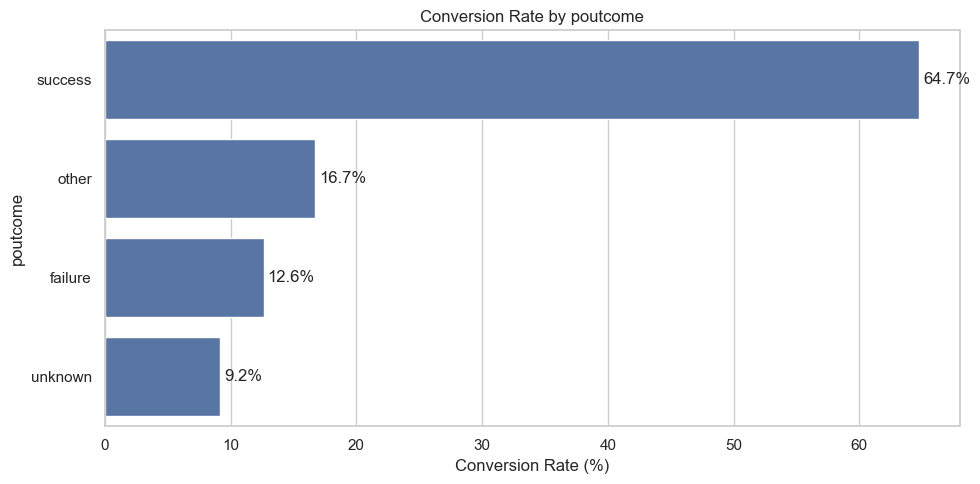

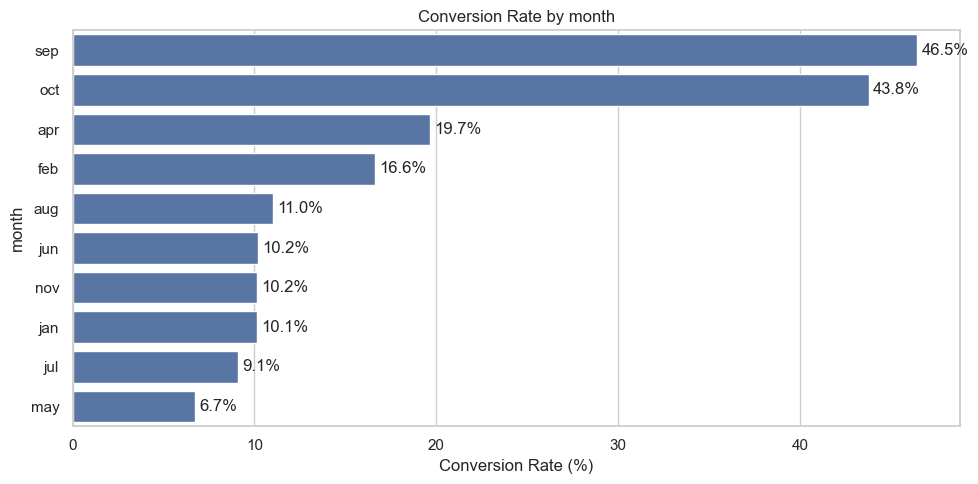

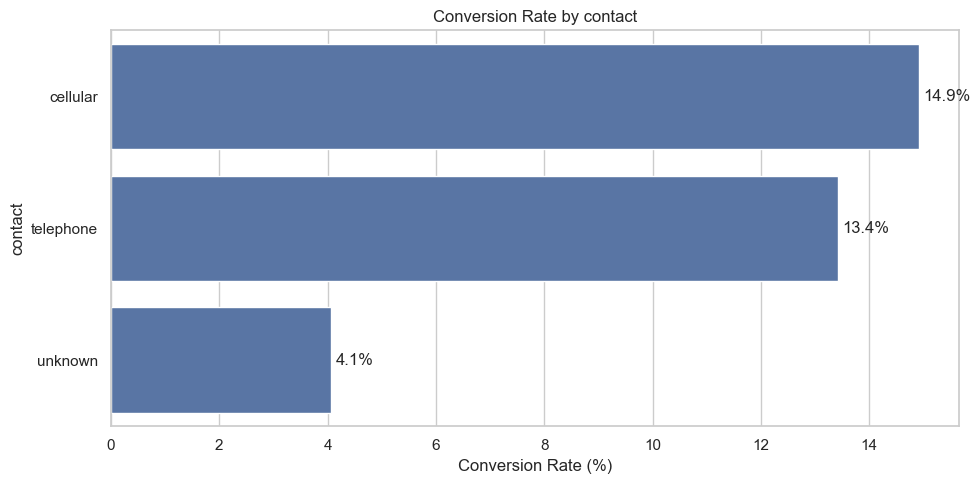

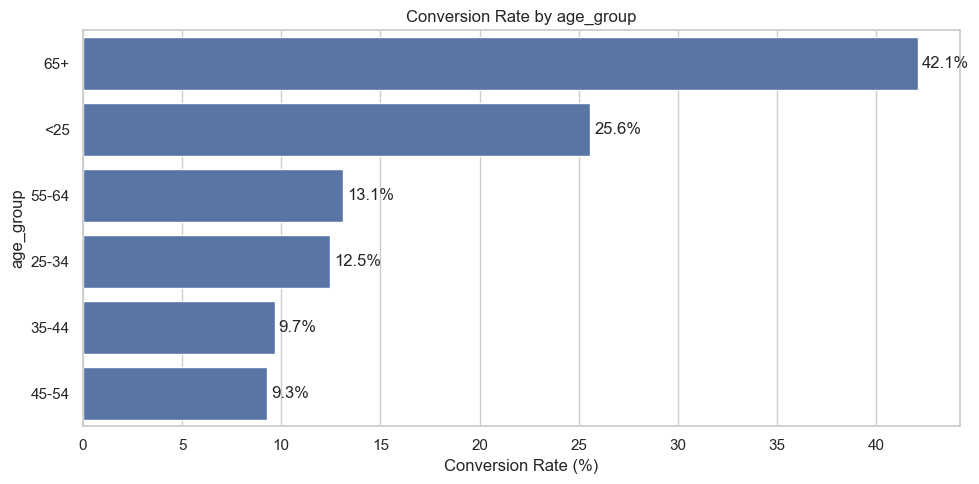

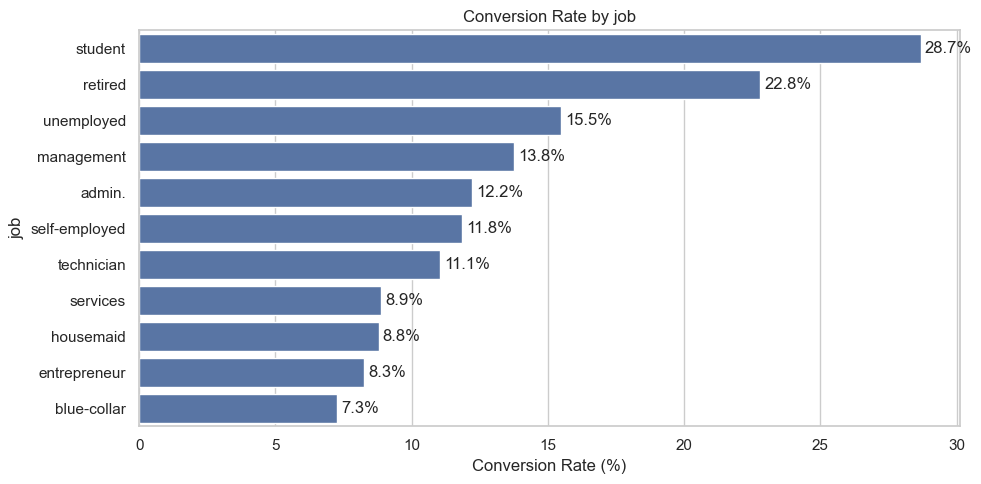

In [40]:
# Plot the segment types created in the SQL segment summary view

preferred_segment_order = [
    'poutcome',
    'month',
    'contact',
    'age_group',
    'job'
]

available_segment_types = sql_segments['segment_type'].unique().tolist()

segments_to_plot = [
    segment for segment in preferred_segment_order
    if segment in available_segment_types
]

print("Segments plotted:")
print(segments_to_plot)

for segment_type in segments_to_plot:
    plot_sql_segment(segment_type, min_customers=500)

**Observation**

The segment plots show which customer and campaign groups have higher conversion rates. These patterns help identify potential targeting opportunities before predictive modeling.

### 3.3 High-Response Segment Summary

In [41]:
# High-response segments with meaningful sample size

high_response_segments = (
    sql_segments
    .query("customers >= 500")
    .sort_values("conversion_rate_pct", ascending=False)
)

high_response_segments.head(20)

,segment_type,segment,customers,subscribers,conversion_rate_pct
28,poutcome,success,1511,978,64.73
14,month,sep,579,269,46.46
19,month,oct,738,323,43.77
35,age_group,65+,810,341,42.10
2,job,student,938,269,28.68
32,age_group,<25,809,207,25.59
7,job,retired,2264,516,22.79
20,month,apr,2932,577,19.68
29,poutcome,other,1840,307,16.68
17,month,feb,2649,441,16.65


**Observation**

High-response segments help identify groups that may be useful for campaign prioritization. The sample-size filter avoids over-interpreting very small segments with unstable conversion rates.

### 3.4 Optional Statistical Association Check

This section provides a compact statistical check of which available categorical variables are most associated with subscription outcome.

In [42]:
def cramers_v(x, y):
    """Calculate Cramer's V association between two categorical variables."""

    confusion_matrix_df = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix_df)[0]
    n = confusion_matrix_df.sum().sum()

    r, k = confusion_matrix_df.shape

    if min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


candidate_association_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'age_group',
    'balance_group',
    'was_previously_contacted',
    'has_any_loan',
    'campaign_contact_group',
    'previous_contact_group'
]

association_features = [
    col for col in candidate_association_features
    if col in df.columns
]

cramer_results = []

for col in association_features:
    cramer_results.append({
        'feature': col,
        'cramers_v': cramers_v(df[col], df['y'])
    })

cramer_summary = (
    pd.DataFrame(cramer_results)
    .sort_values('cramers_v', ascending=False)
)

cramer_summary

,feature,cramers_v
8,poutcome,0.311663
7,month,0.260237
14,previous_contact_group,0.171354
11,was_previously_contacted,0.167174
12,has_any_loan,0.159021
6,contact,0.151355
9,age_group,0.149373
4,housing,0.139103
0,job,0.135990
10,balance_group,0.089425


**Observation**

Cramer's V gives a compact statistical check of which categorical fields are most associated with subscription outcome. This supports the EDA but does not replace modeling.

## 4. Data Preparation for Predictive Modeling

This section prepares data for a pre-campaign targeting model.

The main modeling dataset comes from the SQL analysis-ready view, but the model uses original customer and campaign fields only.

The model excludes:
- `duration`, because it is only known after the customer is contacted
- `campaign`, because it reflects current-campaign contact count and is less appropriate for a pure pre-campaign targeting model

SQL-created grouped fields are useful for EDA and dashboarding, but they are not automatically included in the main model to avoid duplicating information from the original variables.

### 4.1 Select Modeling Features

In [43]:
# Main pre-campaign modeling features

candidate_model_features = [
    'age',
    'job',
    'marital',
    'education',
    'default',
    'balance',
    'housing',
    'loan',
    'contact',
    'day',
    'month',
    'pdays',
    'previous',
    'poutcome'
]

model_features = [
    col for col in candidate_model_features
    if col in df.columns
]

missing_model_features = [
    col for col in candidate_model_features
    if col not in df.columns
]

X = df[model_features].copy()
y = df['y_binary'].copy()

print("Modeling features used:")
print(model_features)

print("\nMissing candidate features not used:")
print(missing_model_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Modeling features used:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'pdays', 'previous', 'poutcome']

Missing candidate features not used:
[]

Feature matrix shape: (45211, 14)
Target shape: (45211,)


### 4.2 Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training feature shape: (36168, 14)
Test feature shape: (9043, 14)

Training target distribution:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64

Test target distribution:
y_binary
0    88.3
1    11.7
Name: proportion, dtype: float64


### 4.3 Preprocessing Pipeline

In [45]:
# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

# Preprocess numerical features
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Preprocess categorical features
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numeric features:
['age', 'balance', 'day', 'pdays', 'previous']


C:\Users\phanh\AppData\Local\Temp\ipykernel_13604\1672694248.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


## 5. Baseline Predictive Modeling

This section compares baseline models for predicting customer subscription.

Because the target is imbalanced, model selection should not rely on accuracy alone. The comparison includes precision, recall, F1-score, and ROC-AUC.

### 5.1 Model Evaluation Function

In [46]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a classification model and return key performance metrics."""

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    print(f"===== {model_name} =====")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return results

### 5.2 Train Baseline Models

In [47]:
# Logistic Regression
log_reg_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

log_reg_results = evaluate_model(
    log_reg_model,
    X_test,
    y_test,
    'Logistic Regression'
)

===== Logistic Regression =====

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043


Confusion Matrix:
[[6189 1796]
 [ 402  656]]


In [48]:
# Decision Tree
tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=5,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_results = evaluate_model(
    tree_model,
    X_test,
    y_test,
    'Decision Tree'
)

===== Decision Tree =====

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7985
           1       0.26      0.59      0.36      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.69      0.61      9043
weighted avg       0.86      0.76      0.79      9043


Confusion Matrix:
[[6229 1756]
 [ 431  627]]


In [49]:
# Random Forest
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    'Random Forest'
)

===== Random Forest =====

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.87      7985
           1       0.31      0.62      0.41      1058

    accuracy                           0.79      9043
   macro avg       0.63      0.72      0.64      9043
weighted avg       0.87      0.79      0.82      9043


Confusion Matrix:
[[6520 1465]
 [ 402  656]]


### 5.3 Model Comparison

In [50]:
model_results = pd.DataFrame([
    log_reg_results,
    tree_results,
    rf_results
])

model_results.sort_values('roc_auc', ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.793542,0.309288,0.620038,0.412708,0.788046
0,Logistic Regression,0.756939,0.267537,0.620038,0.373789,0.768583
1,Decision Tree,0.758155,0.263114,0.592628,0.364429,0.739544


**Takeaway**

The best baseline model should be selected based on overall business usefulness, especially ROC-AUC, recall, precision, and F1-score. ROC-AUC is especially important because campaign targeting depends on ranking customers by predicted subscription probability.

## 6. Campaign Targeting Evaluation

Classification metrics are useful, but campaign targeting needs a business-oriented view.

This section ranks customers by predicted subscription probability and compares the top-ranked groups against the baseline conversion rate.

### 6.1 Select Best Model by ROC-AUC

In [51]:
best_model_name = model_results.sort_values('roc_auc', ascending=False).iloc[0]['model']

model_lookup = {
    'Logistic Regression': log_reg_model,
    'Decision Tree': tree_model,
    'Random Forest': rf_model
}

best_model = model_lookup[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Random Forest


### 6.2 Calculate Targeting Lift

In [52]:
# Predicted probabilities for class 1
y_test_proba = best_model.predict_proba(X_test)[:, 1]

targeting_eval_df = pd.DataFrame({
    'actual_response': y_test.values,
    'predicted_probability': y_test_proba
}).sort_values('predicted_probability', ascending=False).reset_index(drop=True)

baseline_conversion_rate = y_test.mean() * 100

targeting_results = []

for pct in [0.10, 0.20, 0.30, 0.40, 0.50]:
    n_customers = int(len(targeting_eval_df) * pct)
    top_group = targeting_eval_df.head(n_customers)

    conversion_rate = top_group['actual_response'].mean() * 100
    subscribers_captured = top_group['actual_response'].sum()
    total_subscribers = targeting_eval_df['actual_response'].sum()
    capture_rate = subscribers_captured / total_subscribers * 100
    lift = conversion_rate / baseline_conversion_rate

    targeting_results.append({
        'targeted_top_pct': f'Top {int(pct*100)}%',
        'customers_targeted': n_customers,
        'subscribers_captured': int(subscribers_captured),
        'conversion_rate_pct': conversion_rate,
        'capture_rate_pct': capture_rate,
        'baseline_conversion_rate_pct': baseline_conversion_rate,
        'lift_vs_baseline': lift
    })

targeting_results_df = pd.DataFrame(targeting_results)
targeting_results_df

,targeted_top_pct,customers_targeted,subscribers_captured,conversion_rate_pct,capture_rate_pct,baseline_conversion_rate_pct,lift_vs_baseline
0,Top 10%,904,438,48.451327,41.398866,11.699657,4.141260
1,Top 20%,1808,617,34.126106,58.317580,11.699657,2.916847
2,Top 30%,2712,718,26.474926,67.863894,11.699657,2.262881
3,Top 40%,3617,818,22.615427,77.315690,11.699657,1.932999
4,Top 50%,4521,875,19.354125,82.703214,11.699657,1.654247


### 6.3 Visualize Targeting Lift

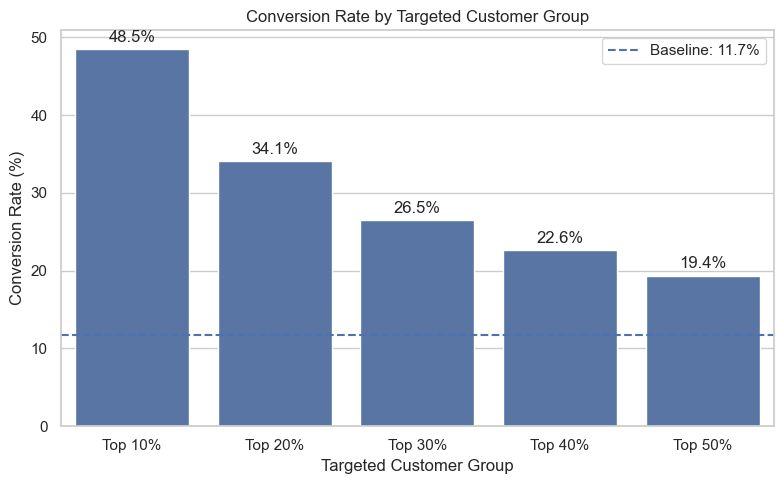

In [53]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=targeting_results_df,
    x='targeted_top_pct',
    y='conversion_rate_pct'
)

plt.axhline(
    baseline_conversion_rate,
    linestyle='--',
    label=f'Baseline: {baseline_conversion_rate:.1f}%'
)

plt.title('Conversion Rate by Targeted Customer Group')
plt.xlabel('Targeted Customer Group')
plt.ylabel('Conversion Rate (%)')
plt.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

**Takeaway**

If the top predicted customer groups have conversion rates above the baseline, the model provides practical value as a customer ranking tool for campaign prioritization.

## 7. Model Interpretation

This section interprets the selected Random Forest model because it is useful for understanding which features contributed most to predictions.

Feature importance should be interpreted as predictive importance, not causal impact.

### 7.1 Extract Feature Names After Preprocessing

In [54]:
# Get feature names after preprocessing from the Random Forest pipeline

# Numeric feature names
numeric_feature_names = numeric_features

# Categorical feature names after one-hot encoding
categorical_feature_names = (
    rf_model
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

# Combine numeric and categorical feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

print("Number of features after preprocessing:", len(all_feature_names))
all_feature_names[:20]

Number of features after preprocessing: 49


['age',
 'balance',
 'day',
 'pdays',
 'previous',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single']

### 7.2 Random Forest Feature Importance


This section extracts feature importance from the trained Random Forest model.

Because categorical variables were one-hot encoded during preprocessing, some features appear as encoded columns such as `poutcome_success`, `contact_unknown`, and `month_may`.

This view helps identify which specific processed features were most useful for the model's predictions.


In [55]:
# Get feature importance from the Random Forest model
rf_feature_importance = rf_model.named_steps['model'].feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_feature_importance
}).sort_values('importance', ascending=False)

feature_importance_df.head(20)

,feature,importance
47,poutcome_success,0.151409
32,contact_unknown,0.106263
3,pdays,0.073963
26,housing_no,0.064689
0,age,0.064056
30,contact_cellular,0.059048
27,housing_yes,0.055328
1,balance,0.044844
4,previous,0.041146
48,poutcome_unknown,0.037680


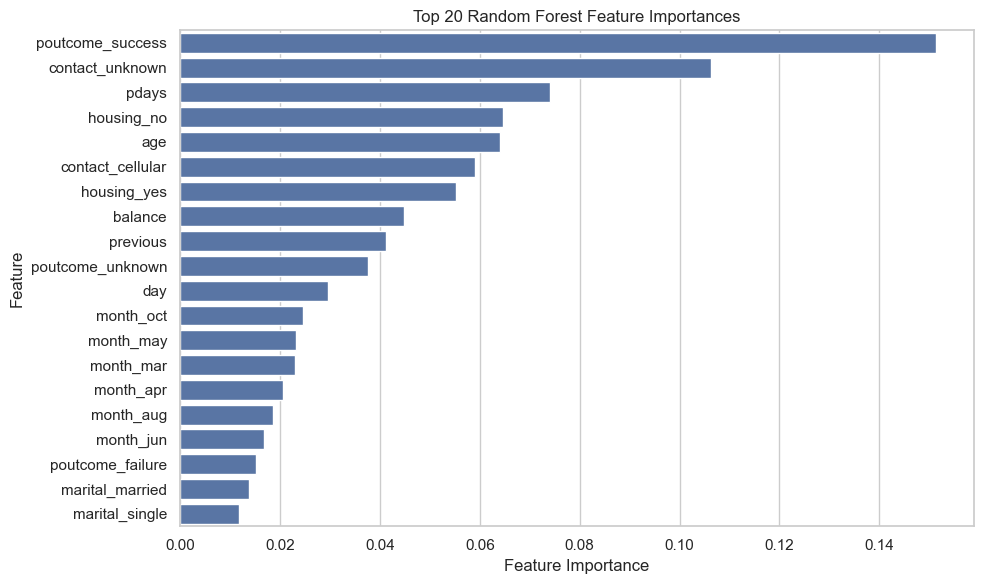

In [56]:
top_n = 20

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=feature_importance_df.head(top_n),
    x='importance',
    y='feature'
)

plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### 7.3 Feature Importance by Original Variable

The previous feature importance table shows importance at the encoded feature level.

However, one original categorical variable can be split into many encoded columns. For example, month becomes features such as month_may, month_apr, and month_oct.

To make the results easier to interpret for business users, this section maps encoded features back to their original variables and sums their importance.

In [57]:
def map_to_original_feature(feature_name, original_features):
    """Map one-hot encoded feature names back to the original variable name."""

    for original_feature in original_features:
        if feature_name == original_feature:
            return original_feature

        if feature_name.startswith(original_feature + "_"):
            return original_feature

    return feature_name


# Map encoded features back to original feature groups
feature_importance_df['original_feature'] = feature_importance_df['feature'].apply(
    lambda x: map_to_original_feature(x, model_features)
)

# Aggregate importance by original feature
grouped_feature_importance = (
    feature_importance_df
    .groupby('original_feature', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

grouped_feature_importance

,original_feature,importance
12,poutcome,0.209280
2,contact,0.170621
10,month,0.157897
6,housing,0.120017
11,pdays,0.073963
0,age,0.064056
1,balance,0.044844
13,previous,0.041146
3,day,0.029635
7,job,0.027900


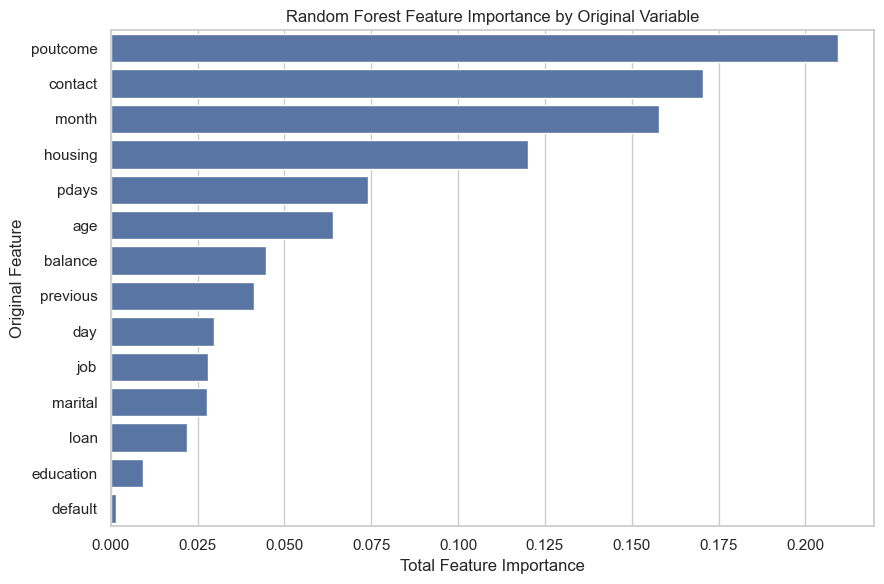

In [58]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=grouped_feature_importance,
    x='importance',
    y='original_feature'
)

plt.title('Random Forest Feature Importance by Original Variable')
plt.xlabel('Total Feature Importance')
plt.ylabel('Original Feature')

plt.tight_layout()
plt.show()

**Model Interpretation Takeaway**

The grouped feature importance view is easier to interpret than the one-hot encoded feature table because it summarizes importance back to the original variables.

These results should be compared with the SQL segment summary and Python EDA. If the model places high importance on variables that also showed meaningful conversion differences in SQL/EDA, the project story becomes more coherent.

## 8. Business Recommendations

Based on the segment analysis, predictive modeling, targeting lift evaluation, and model interpretation, the bank should use probability-based targeting instead of random customer selection.

Recommended actions:

- Use the selected model to rank customers by predicted subscription probability.
- Prioritize the highest-probability customer groups when campaign capacity is limited.
- Compare targeted conversion rates against the SQL baseline campaign conversion rate.
- Combine demographic information with campaign context and previous campaign behavior.
- Use the model as a ranking tool, not only as a fixed yes/no classifier.

## 9. Final Project Summary and Limitations

This project combines SQL and Python to build an end-to-end campaign targeting analysis.

SQL prepares the analysis-ready data and business summary views, while Python extends the analysis through visualization, predictive modeling, targeting evaluation, and model interpretation.

Limitations:

- The model is trained on historical campaign data, so future performance should be monitored.
- Feature importance shows predictive usefulness, not causal impact.
- Business constraints such as call cost, campaign capacity, and contact limits are not included yet.
- Future work could use cross-validation and financial impact modeling.